In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Alati su spremni!")

Alati su spremni!


In [5]:
df = pd.read_csv(r'C:\Users\x\Desktop\archive\balance-scale.csv');

In [6]:
df.head(5)

,Class,L-Weight,L-Distance,R-Weight,R-Distance
0,B,1,1,1,1
1,R,1,1,1,2
2,R,1,1,1,3
3,R,1,1,1,4
4,R,1,1,1,5


In [7]:
#provjera sta se nalazi u Class, sa čime raspolažemo
print(df['Class'].value_counts());

Class
R    288
L    288
B     49
Name: count, dtype: int64


In [12]:
#definniranje cilja
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
print('Podatci su podijeljeni')

Podatci su podijeljeni


In [14]:
model_sirovi = RandomForestClassifier(random_state=42)
model_sirovi.fit(X_train, y_train)

#predviđeni rezultat
y_pred_sirovi = model_sirovi.predict(X_test)

#ispis točnosti
print(f"Točnost sirovog modela: {accuracy_score(y_test, y_pred_sirovi):.2%}")

Točnost sirovog modela: 80.80%


In [15]:
print(classification_report(y_test, y_pred_sirovi))

              precision    recall  f1-score   support

           B       0.00      0.00      0.00        11
           L       0.84      0.95      0.89        55
           R       0.88      0.83      0.85        59

    accuracy                           0.81       125
   macro avg       0.57      0.59      0.58       125
weighted avg       0.78      0.81      0.79       125



In [ ]:
#pošto je za B sve 0.00; popravljamo model

In [20]:
df['L_Moment'] = df['L-Weight'] * df['L-Distance']
df['R_Moment'] = df['R-Weight'] * df['R-Distance']

X_novo = df.drop('Class', axis=1)
y_novo = df['Class']

X_train2, X_test2, y_train2, y_test2 = train_test_split (X_novo, y_novo, test_size=0.2, random_state=42)


#novi model
model_novo = RandomForestClassifier(random_state=42)
model_novo.fit(X_train2, y_train2)

#predviđeni rezultat
y_pred_novo = model_novo.predict(X_test2)

print(f"Nova točnost: {accuracy_score(y_test2, y_pred_novo):.2%}")
print("\nNovi izvještaj:")
print(classification_report(y_test2, y_pred_novo))

Nova točnost: 89.60%

Novi izvještaj:
              precision    recall  f1-score   support

           B       0.00      0.00      0.00        11
           L       0.92      1.00      0.96        55
           R       0.90      0.97      0.93        59

    accuracy                           0.90       125
   macro avg       0.61      0.66      0.63       125
weighted avg       0.83      0.90      0.86       125



In [25]:
#provjera jesu li lijeva i desna strana jednake
df['Jesu_li_jedanki'] = (df['L-Distance'] == df['R-Distance']).astype(int)

X_zadnje = df.drop('Class', axis=1)
y_zadnje = df['Class']

X_train_z, X_test_z, y_train_z, y_test_z = train_test_split(X_zadnje, y_zadnje, test_size=0.2, random_state=42)

#Radimo model, ali mu kažemo da obrati POSEBNU pažnju na rijetke klase (class_weight)
model_z = RandomForestClassifier(class_weight='balanced', random_state=42)
model_z.fit(X_train_z, y_train_z)
y_pred_z = model_z.predict(X_test_z)
print(classification_report(y_test_z, y_pred_z))

              precision    recall  f1-score   support

           B       0.25      0.09      0.13        11
           L       0.90      0.98      0.94        55
           R       0.90      0.93      0.92        59

    accuracy                           0.88       125
   macro avg       0.68      0.67      0.66       125
weighted avg       0.84      0.88      0.86       125



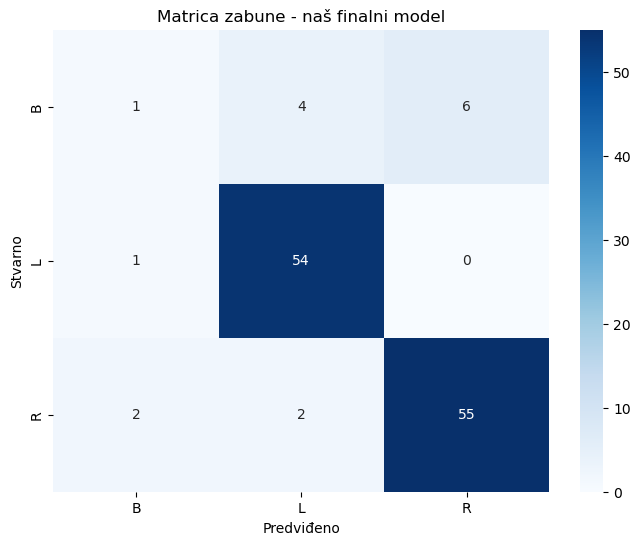

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Računamo matricu zabune
cm = confusion_matrix(y_test_z, y_pred_z)
# Crtamo je pomoću Seaborn biblioteke
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['B', 'L', 'R'], 
            yticklabels=['B', 'L', 'R'])
plt.xlabel('Predviđeno')
plt.ylabel('Stvarno')
plt.title('Matrica zabune - naš finalni model')
plt.show()